# **Random Forest Regression Model**

**Team 3 | ECS 171 | Shreyans Porwal**

This notebook implements a Random Forest Regressor as a nonlinear ensemble model.

The pipeline follows the team's agreed workflow:
- Load the team's feature-selected dataset
- 75 / 25 train-test split
- 5-fold cross-validation for hyperparameter tuning
- Train a baseline Random Forest model
- Evaluate performance using RMSE, MAE, and R²
- Tune hyperparameters
- Analyze feature importance

### **1. Imports**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")

### **2. Load Dataset**

In [7]:
#import os
#os.chdir("../../")

In [8]:
df = pd.read_csv("data/processed/housing_feature_selected.csv")

### **3. Define Features and Target**

In [9]:
TARGET = 'median_house_value'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 8)
Target shape: (20640,)


### **4. Train/Test Split (75/25)**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (15480, 8) (15480,)
Test shape: (5160, 8) (5160,)


### **5. Baseline Model**

In [11]:
rf_baseline = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)
y_pred = rf_baseline.predict(X_test)

# Errors
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Baselin eRMSE: {rmse:,.2f}")
print(f"Baseline MAE:  {mae:,.2f}")
print(f"Baseline R²:   {r2:.4f}")

Baselin eRMSE: 68,680.06
Baseline MAE:  47,517.82
Baseline R²:   0.6435


### **6. Residuals**

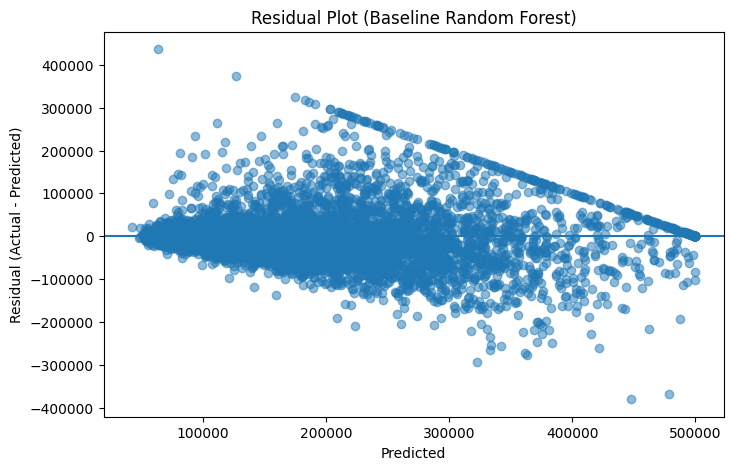

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Baseline Random Forest)")
plt.show()

**Residual Analysis**:

The residual plot shows increasing variance for higher predicted house values, which demonstrates heteroskedasticity. This is common in housing datasets because more expensive homes have higher variability. The upper diagonal boundary is because the dataset's price cap is at $500,000. Most importantly, the residuals are mostly centered around zero, which suggests that there is no strong systematic bias in the model's predictions.

### **7. Hyperparameter Tuning (5-Fold CV)**

In [13]:
# Define parameter grid
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Best CV RMSE: -64984.25827884241


### **8. Evaluation on Test Set**

In [14]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print(f"RMSE: {rmse_tuned:,.2f}")
print(f"MAE:  {mae_tuned:,.2f}")
print(f"R²:   {r2_tuned:.4f}")

Tuned Random Forest Results
RMSE: 65,167.03
MAE:  45,685.09
R²:   0.6791


### **9. Model Performance Comparison**

In [15]:
results = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF"],
    "RMSE": [rmse, rmse_tuned],
    "MAE": [mae, mae_tuned],
    "R2": [r2, r2_tuned]
})

results

,Model,RMSE,MAE,R2
0,Baseline RF,68680.058779,47517.821054,0.643524
1,Tuned RF,65167.031892,45685.094331,0.679060


**Model Comparison**:

The hyperparameter tuning improved model performance, reduced RMSE from 68860 to 65167 and increased R^2 from 0.64 to 0.68. This shows an improved generalization performance and better capture of the nonlinear feature interactions when compared to the baseline random forest model.

### **10. Final Model Selection**

Based on the cross-validation and test set performance, the tuned Random Forest model is selected as the final model.

- RMSE = 65,167
- MAE = 45,685
- R² = 0.679

The improvement over the baseline model shows that the hyperparameter tuning enhances generalization rather than overfitting the data.

### **11. Feature Importance**

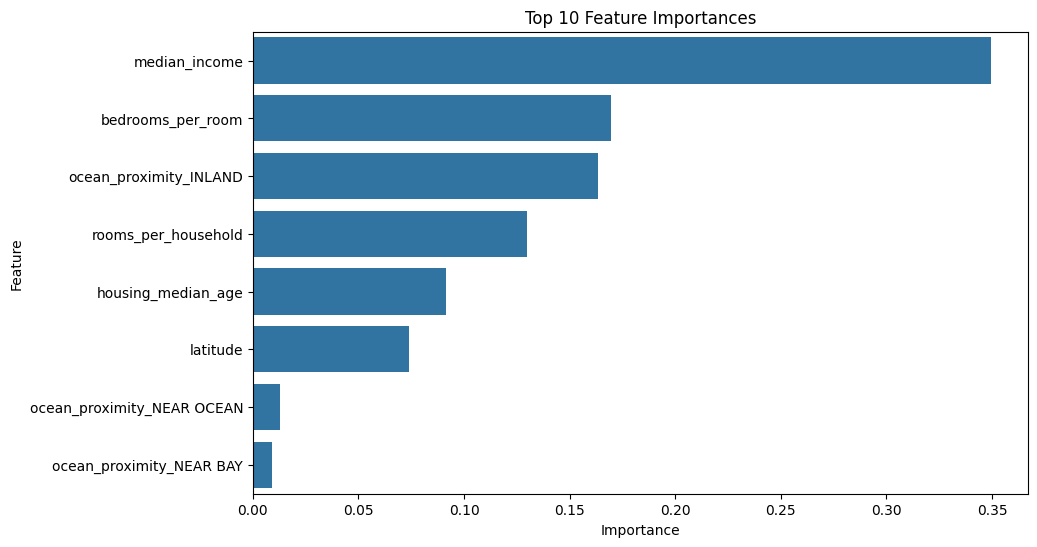

In [18]:
feature_importances = pd.Series(
    best_rf.feature_importances_,   # or best_rf if that's your name
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Feature Importance Analysis**:

Median income is the most influential predictor of the target feature, median house value. It indicates that higher income areas strongly correlate with higher housing prices.

Housing characteristics like bedrooms per room and rooms per household show that housing density and living space quality correlate with higher housing prices.

Location-based features differ in correlation. Features like near the ocean or near the bay have little to no correlation with the target feature. While the inland feature has high correlation with higher housing prices.